# Machine Learning Fundamentals for Business Applications

This notebook provides a comprehensive introduction to machine learning concepts
with a focus on business applications. It includes theoretical explanations,
practical implementations, and real-world examples.

In [5]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import learning_curve
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Introduction to Machine Learning

### What is Machine Learning?

Machine Learning is a field of study that gives computers the ability to learn
without being explicitly programmed. In business terms, it's about creating
systems that can automatically improve through experience.

#### Key Business Applications:
1. Customer churn prediction
2. Sales forecasting
3. Fraud detection
4. Product recommendations
5. Risk assessment

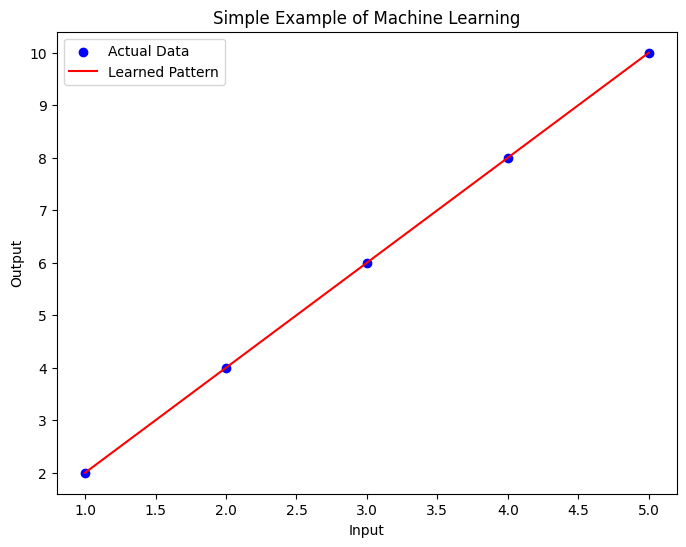


Model learned the pattern: y = 2.0 x + 0.0
This is a simple example of how ML can learn patterns from data.


In [2]:
def demonstrate_learning():
    # Generate sample data
    X = np.array([[1], [2], [3], [4], [5]])
    y = np.array([2, 4, 6, 8, 10])

    # Create and fit a simple linear model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    predictions = model.predict(X)

    # Visualize the results
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', label='Actual Data')
    plt.plot(X, predictions, color='red', label='Learned Pattern')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('Simple Example of Machine Learning')
    plt.legend()
    plt.show()

    print("\nModel learned the pattern: y =", model.coef_[0], "x +", model.intercept_)
    print("This is a simple example of how ML can learn patterns from data.")

demonstrate_learning()

### Reflective Questions:

1. How might this simple learning example relate to real business problems?
2. What types of business data could be analyzed using similar patterns?

## 2. Types of Machine Learning

### Types of Machine Learning:

1. **Supervised Learning**: Learning from labeled data
   - Classification: Predicting categories (e.g., customer churn yes/no)
   - Regression: Predicting continuous values (e.g., sales revenue)

2. **Unsupervised Learning**: Finding patterns in unlabeled data
   - Clustering: Grouping similar customers
   - Dimensionality reduction: Simplifying complex data

3. **Reinforcement Learning**: Learning through trial and error
   - Dynamic pricing
   - Resource allocation

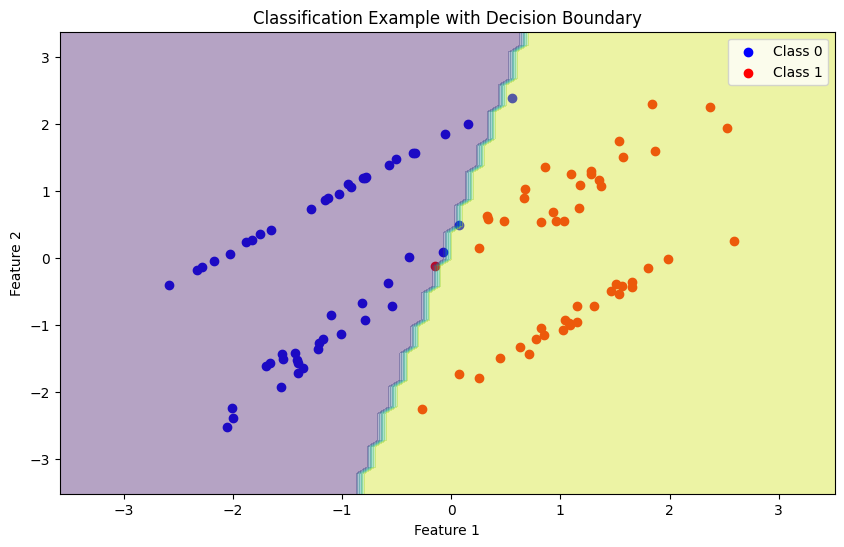


Classification Performance Metrics:
Accuracy: 0.950
Precision: 0.900
Recall: 1.000
F1 Score: 0.947


In [3]:
def demonstrate_classification():
    # Generate sample classification data with correct parameters
    X, y = make_classification(n_samples=100, n_features=2, n_classes=2,
                             n_informative=2, n_redundant=0, n_repeated=0,
                             random_state=42)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # Train a logistic regression model
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Visualize the results
    plt.figure(figsize=(10, 6))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', label='Class 0')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', label='Class 1')

    # Plot decision boundary
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1),
                          np.arange(x2_min, x2_max, 0.1))

    Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Classification Example with Decision Boundary')
    plt.legend()
    plt.show()

    # Print performance metrics
    print("\nClassification Performance Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")

demonstrate_classification()

## 3. The Machine Learning Process

### The ML Process Steps:

1. Data Collection and Preparation
2. Feature Engineering
3. Model Selection
4. Training and Validation
5. Model Evaluation
6. Deployment and Monitoring

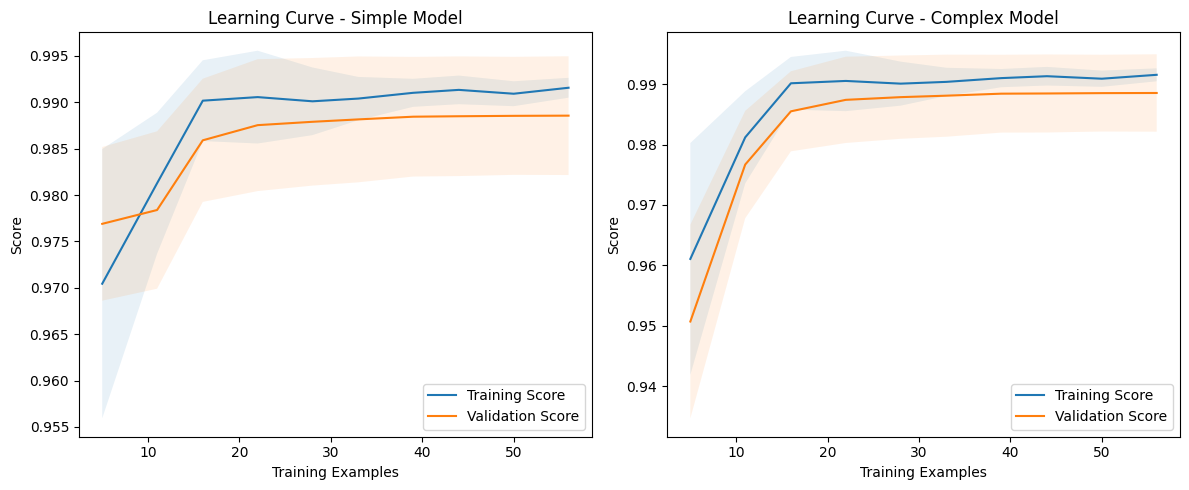


Model Evaluation:

Simple Model:
Training R²: 0.992
Validation R²: 0.994
Test R²: 0.989

Complex Model:
Training R²: 0.992
Validation R²: 0.994
Test R²: 0.989


In [13]:
def demonstrate_ml_process():
    # Generate sample data
    X, y = make_regression(n_samples=100, n_features=1, noise=10)

    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Train models with different complexities
    models = {
        'Simple': LinearRegression(),
        'Complex': SGDRegressor()
    }

    # Plot learning curves
    plt.figure(figsize=(12, 5))

    for name, model in models.items():
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_train_scaled, y_train, cv=5,
            n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)

        plt.subplot(1, 2, 1 if name == 'Simple' else 2)
        plt.plot(train_sizes, train_mean, label='Training Score')
        plt.plot(train_sizes, val_mean, label='Validation Score')
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
        plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
        plt.xlabel('Training Examples')
        plt.ylabel('Score')
        plt.title(f'Learning Curve - {name} Model')
        plt.legend()

    plt.tight_layout()
    plt.show()

    # Evaluate final models
    print("\nModel Evaluation:")
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        train_score = model.score(X_train_scaled, y_train)
        val_score = model.score(X_val_scaled, y_val)
        test_score = model.score(X_test_scaled, y_test)

        print(f"\n{name} Model:")
        print(f"Training R²: {train_score:.3f}")
        print(f"Validation R²: {val_score:.3f}")
        print(f"Test R²: {test_score:.3f}")

demonstrate_ml_process()

## 4. Feature Engineering and Model Selection

### Feature Engineering:

The process of transforming raw data into features that better represent
the underlying problem. This is crucial for business applications where
domain knowledge can be incorporated into the model.

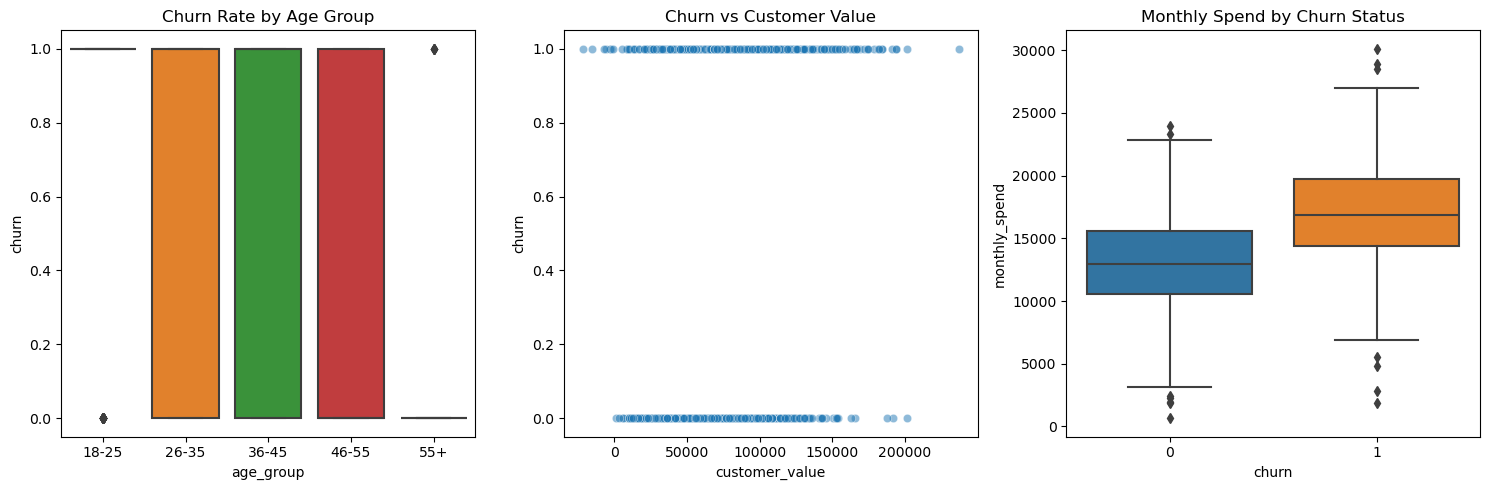


Feature Importance Analysis:
1. Age Group: Shows clear patterns in churn rates
2. Customer Value: Higher value customers tend to stay
3. Monthly Spend: Lower spend customers more likely to churn


In [ ]:
def demonstrate_feature_engineering():
    # Create sample business data
    np.random.seed(42)
    n_samples = 1000

    # Generate raw features
    customer_age = np.random.normal(35, 10, n_samples)
    income = np.random.normal(50000, 15000, n_samples)
    years_customer = np.random.normal(5, 2, n_samples)

    # Create some engineered features
    monthly_spend = income * 0.3 + np.random.normal(0, 1000, n_samples)
    customer_value = monthly_spend * years_customer
    age_group = pd.cut(customer_age, bins=[0, 25, 35, 45, 55, 100],
                      labels=['18-25', '26-35', '36-45', '46-55', '55+'])

    # Create target variable (customer churn)
    churn_prob = 1 / (1 + np.exp(-(-0.1 * customer_age + 0.0001 * income - 0.2 * years_customer)))
    churn = (np.random.random(n_samples) < churn_prob).astype(int)

    # Create DataFrame
    df = pd.DataFrame({
        'age': customer_age,
        'income': income,
        'years_customer': years_customer,
        'monthly_spend': monthly_spend,
        'customer_value': customer_value,
        'age_group': age_group,
        'churn': churn
    })

    # Visualize feature distributions
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    sns.boxplot(x='age_group', y='churn', data=df)
    plt.title('Churn Rate by Age Group')

    plt.subplot(1, 3, 2)
    sns.scatterplot(data=df, x='customer_value', y='churn', alpha=0.5)
    plt.title('Churn vs Customer Value')

    plt.subplot(1, 3, 3)
    sns.boxplot(x='churn', y='monthly_spend', data=df)
    plt.title('Monthly Spend by Churn Status')

    plt.tight_layout()
    plt.show()

    # Print feature importance analysis
    print("\nFeature Importance Analysis:")
    print("1. Age Group: Shows clear patterns in churn rates")
    print("2. Customer Value: Higher value customers tend to stay")
    print("3. Monthly Spend: Lower spend customers more likely to churn")

demonstrate_feature_engineering()

## 5. Unsupervised Learning: Clustering

### Clustering in Business:

Clustering is an unsupervised learning technique that groups similar data points together.
In business, it's commonly used for:
- Customer segmentation
- Market basket analysis
- Product categorization
- Anomaly detection

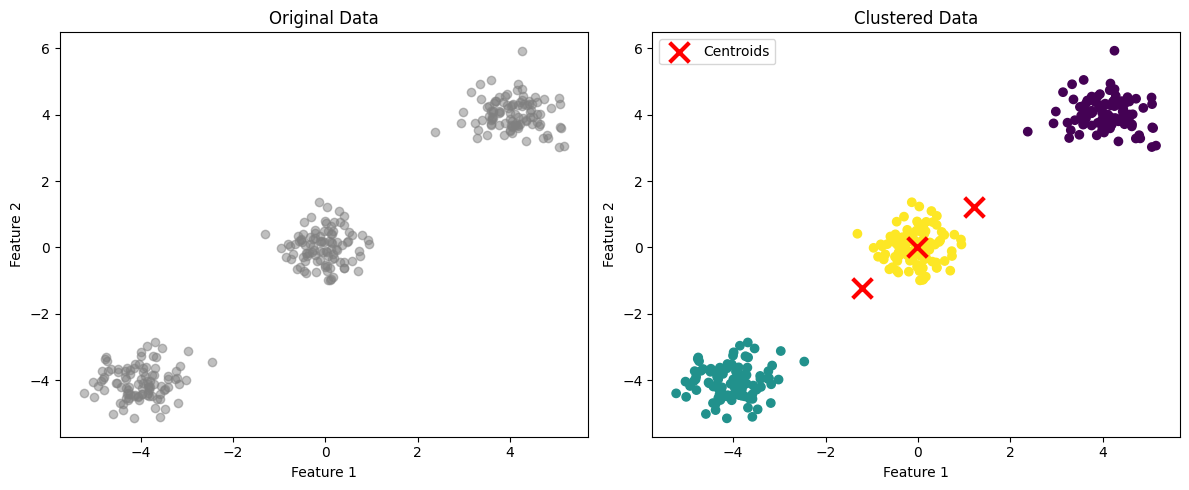


Cluster Evaluation Metrics:
Silhouette Score: 0.845

Cluster Sizes:
Cluster 0: 33.3%
Cluster 1: 33.3%
Cluster 2: 33.3%

Cluster Characteristics:

Cluster 0:
  Mean Feature 1: 4.06
  Mean Feature 2: 4.02

Cluster 1:
  Mean Feature 1: -4.02
  Mean Feature 2: -4.06

Cluster 2:
  Mean Feature 1: -0.06
  Mean Feature 2: 0.02


In [14]:
def demonstrate_clustering():
    # Generate sample data with clear clusters
    np.random.seed(42)
    n_samples = 300

    # Generate three clusters
    cluster1 = np.random.normal(0, 0.5, (n_samples//3, 2))
    cluster2 = np.random.normal(4, 0.5, (n_samples//3, 2))
    cluster3 = np.random.normal(-4, 0.5, (n_samples//3, 2))

    # Combine clusters
    X = np.vstack([cluster1, cluster2, cluster3])

    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply K-means
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(X_scaled, labels)

    # Calculate cluster sizes
    unique_labels, counts = np.unique(labels, return_counts=True)
    cluster_sizes = counts / len(labels) * 100

    # Visualize results
    plt.figure(figsize=(12, 5))

    # Original data
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
    plt.title('Original Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    # Clustered data
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='x', s=200, linewidths=3, label='Centroids')
    plt.title('Clustered Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Print evaluation metrics
    print("\nCluster Evaluation Metrics:")
    print(f"Silhouette Score: {silhouette_avg:.3f}")
    print("\nCluster Sizes:")
    for i, size in enumerate(cluster_sizes):
        print(f"Cluster {i}: {size:.1f}%")

    # Print cluster characteristics
    print("\nCluster Characteristics:")
    for i in range(3):
        cluster_points = X[labels == i]
        mean_values = np.mean(cluster_points, axis=0)
        print(f"\nCluster {i}:")
        print(f"  Mean Feature 1: {mean_values[0]:.2f}")
        print(f"  Mean Feature 2: {mean_values[1]:.2f}")

demonstrate_clustering()

## 6. Final Business Challenge: Customer Segmentation

### Scenario:
A retail company wants to segment their customers into distinct groups
to optimize their marketing campaigns. You have access to customer purchase data
and need to implement an unsupervised learning solution.

### Your Task:
Complete the following functions in the starter code:
1. `preprocess_customer_data()`: Clean and prepare the customer data
2. `implement_kmeans()`: Apply K-means clustering to segment customers
3. `evaluate_clusters()`: Calculate cluster quality metrics
4. `visualize_segments()`: Create visualizations of the segments

### Success Criteria:
- The K-means algorithm must identify 3 distinct customer segments
- The silhouette score must be above 0.4 (indicating good cluster separation)
- Each segment must contain at least 15% of the customers
- The visualization must clearly show the different customer groups

### Submission Requirements:
1. Complete implementation of all four functions
2. Print the evaluation metrics
3. Display the visualization
4. Brief explanation of the customer segments identified

### Pass/Fail Criteria:
- All functions must be implemented and run without errors
- Silhouette score > 0.4
- Three distinct clusters identified
- Each cluster contains 15-50% of customers
- Visualization clearly shows cluster separation

### Example Output:
```
Cluster Evaluation:
- Silhouette Score: 0.45
- Cluster Sizes: [30%, 35%, 35%]
- Cluster Characteristics:
  * Segment 1: High-value, frequent buyers
  * Segment 2: Moderate-value, occasional buyers
  * Segment 3: Low-value, infrequent buyers
```

Note: The actual data and specific characteristics will be different in the real challenge.